In [1]:
import dnois
from dnois.optics import rt
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_grad_enabled(False)

## Create lens and camera

In [3]:
sq = rt.CoaxialSurfaceSequence.load_json('double-gauss.json')
sensor = dnois.sensor.StandardSensor(512, 2e-6, noise_std=1e-2)
optics = rt.CoaxialRayTracing(
    sq,
    sensor,
    perspective_focal_length=0.1,
    sampler=sq[0].aperture.sampler('unipolar', 64, 36),
    wl=[dnois.fline('F'), dnois.fline('d', 'He'), dnois.fline('C')],
    depth=float('inf'),
)

camera = dnois.Camera(optics, sensor)
camera.double()
camera.to(device=device)

Camera(
  (optics): CoaxialRayTracing(
    (surfaces): CoaxialSurfaceSequence(
      (0): Spherical(
        material=SK2, reflective=False,
        roc=0.0541532m
        (aperture): CircularAperture(radius=0.0293392m)
        (context): CoaxialContext(distance=0.00874666m)
      )
      (1): Spherical(
        material=vacuum, reflective=False,
        roc=0.152522m
        (aperture): CircularAperture(radius=0.0282666m)
        (context): CoaxialContext(distance=0.0005m)
      )
      (2): Spherical(
        material=SK16, reflective=False,
        roc=0.0359506m
        (aperture): CircularAperture(radius=0.0243546m)
        (context): CoaxialContext(distance=0.014m)
      )
      (3): Spherical(
        material=F5, reflective=False,
        roc=inf
        (aperture): CircularAperture(radius=0.0213582m)
        (context): CoaxialContext(distance=0.00377697m)
      )
      (4): Spherical(
        material=vacuum, reflective=False,
        roc=0.0222699m
        (aperture): Circula

## Paraxial features of the lens

In [4]:
r, z = optics.entr_pupil()
print('Entrance pupil')
print('Diameter: ', dnois.Length.fmt(r.item() * 2, 'mm'))
print('Position: ', dnois.Length.fmt(z.item(), 'mm'))

Entrance pupil
Diameter:  33.3414mm
Position:  58.9398mm


In [5]:
r, z = optics.exit_pupil()
print('Exit pupil')
print('Diameter: ', dnois.Length.fmt(r.item() * 2, 'mm'))
print('Position: ', dnois.Length.fmt(z.item(), 'mm'))
print('Relative to image plane: ', dnois.Length.fmt((z - sq.total_length).item(), 'mm'))

Exit pupil
Diameter:  36.2708mm
Position:  24.9288mm
Relative to image plane:  -108.06mm


In [6]:
print(f'Focal length: {optics.focal_length1()}')

Focal length: 0.09950067221635131


## Cross section

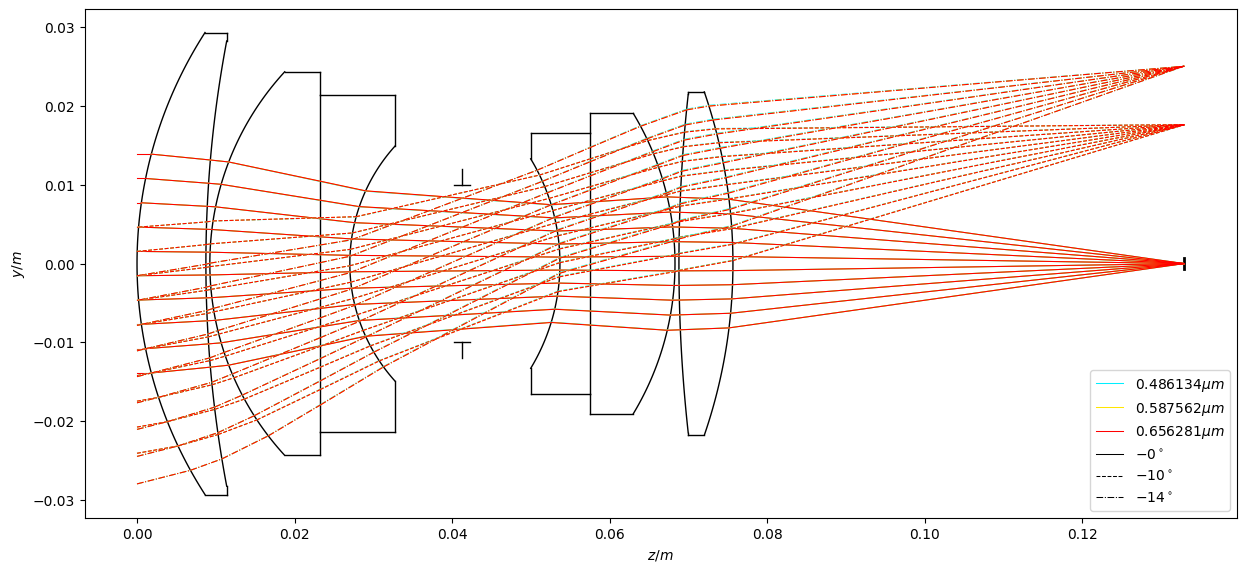

In [7]:
_ = optics.plot_cross_section(height=optics.new_tensor([0, 10, 14]).deg2rad().tan())

## Point spread function

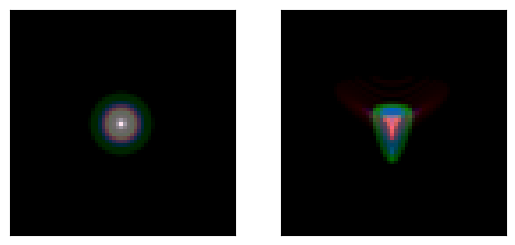

In [8]:
obj = optics.fovd2obj(torch.tensor([(0., 0.), (0., 14.)]).deg2rad().to(device), float('inf'))
psf = optics.psf(obj, psf_model='inc_rect', psf_center='mean')

fig, axs = plt.subplots(1, psf.size(0))
for i, ax in enumerate(axs):
    psf_show = psf[i]
    psf_show = psf_show / psf_show.sum((-2, -1), True)
    psf_show = psf_show / psf_show.max()
    psf_show = psf_show ** 0.5
    ax.imshow(dnois.utils.t4plot(psf_show.permute(1, 2, 0)))
    ax.set_xticks([])
    ax.set_yticks([])

## Imaging simulation

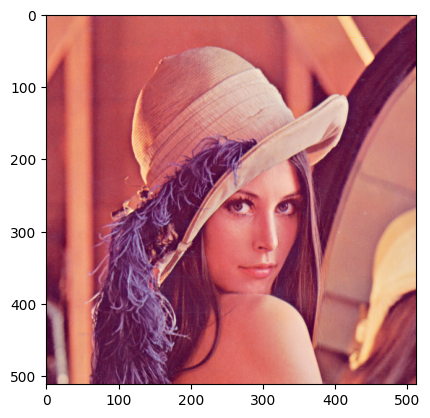

In [9]:
img_path = '../assets/LenaRGB.bmp'
img = Image.open(img_path)
img = torch.from_numpy(np.array(img)) / 255.
img = img.permute(2, 0, 1)
img = img.to(device=device)
img_linear = dnois.isp.srgb2linear(img)
scene = dnois.scene.ImageScene(img_linear, batched=False).batch()

plt.imshow(img.permute(1, 2, 0).clamp(0, 1).cpu())

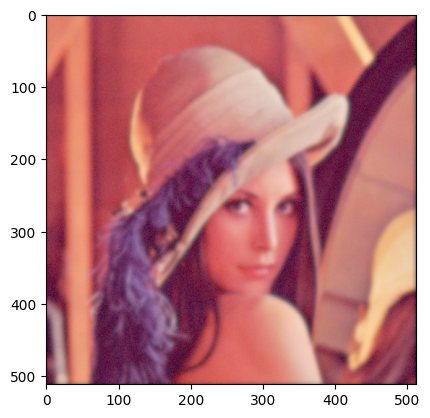

In [10]:
captured = camera(scene)
plt.imshow(captured.squeeze(0).permute(1, 2, 0).clamp(0, 1).cpu())